In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif

# Exploratory Data Analysis and Data Understanding

In [2]:
# Load Dataset (Ensure the file is in your directory)
df= pd.read_csv('/content/drive/MyDrive/Datasets/appendix_cancer_prediction_dataset.csv')



## Dataset Description

The dataset was created/uploaded to Kaggle by Ankush Pandey approximately in early 2024. The data set was accessed via kaggle by searching for appendix cancer prediction datasets.

This dataset aligns with the United Nations Sustainable Development Goal 3: Good health and well being because by developing such models for different kinds of cancer, researchers can improve early detection and prevention rates which improves the overall health of people around the world and lessens the health burden of such non communicable diseases.

The attributes of the dataset are as follows:




*   Patient_ID : a Column of unique patient IDs

*   Country: The geographic location of the patient, which can be used to identify regional health trends or environmental risk factors.

*   Age: The patient's chronological age (18–89), a critical factor as cancer risk typically increases with physiological aging.

*   Gender: The biological sex of the patient, used to analyze demographic differences in cancer prevalence.

*   BMI: The measure of a person's body fat according to their height and weight.

*   Smoking_Status :A binary indicator (Yes/No) of tobacco use, which is a well-documented carcinogen and a major risk factor for various cancers.


*   Alcohol_Consumption: Categorizes the patient’s frequency of alcohol intake (Low, Moderate, High) to evaluate its impact on cellular health.


*   Family_History_Cancer :Indicates whether biological relatives have had cancer.

*   Genetic Mutations: Identifies the presence of specific DNA markers known to increase the likelihood of developing oncological conditions.


*  Chronic diseases: Records pre-existing long-term health issues, such as hypertension or diabetes, which can complicate cancer prognosis.


*   Physical_Activity_Level: Measures how often the patient exercises (Low, Moderate, High), reflecting general lifestyle health and immune resilience.


*  Diet_Type: Classifies the patient’s eating habits (Vegetarian/Non-Vegetarian) to study the link between nutrition and cancer risk.

*  Radiation_Exposure: A binary field indicating if the patient has a history of exposure to ionizing radiation, a known trigger for DNA damage.



*   Previous_Cancers: Documents if the patient has survived prior malignancies, which may increase the risk of secondary cancer development.

*   Blood_Pressure: Measures the force of blood against artery walls (Systolic, in mmHg), serving as a marker for cardiovascular and systemic health.


*   Cholestrol_Level: The total amount of cholesterol in the blood; high levels can indicate metabolic issues or poor dietary health.

*   White_Blood_Cell_Count : A clinical measure of immune system cells (cells/µL); abnormal levels may indicate infection or an immune response to a tumor.

*   Red_Blood_Cell_Count : The concentration of oxygen-carrying cells in the blood; low counts can indicate anemia or systemic illness. : RBC counts are expressed in $10^6/\mu\text{L}$

*   Platelet_Count : Measures the blood's clotting ability; significant fluctuations can be observed in patients with certain types of cancer.

*   Tumor_Markers : Biochemical substances found in the blood that are produced by cancer cells or by the body in response to cancer.
*   Symptom_Severity : : A qualitative or quantitative scale reflecting the intensity of physical distress reported by the patient.


*   Treatment_Type : The specific medical intervention assigned to the patient (e.g., Surgery, Chemotherapy, or Radiation).


*   Survival_Years_After_Diagnosis : A numerical value tracking the duration of a patient’s life post-diagnosis, used for longitudinal health studies.


*   Appendix_Cancer : The binary target variable (0 or 1) indicating whether the patient was ultimately diagnosed with appendix cancer.







## Meaningful questions that the dataset can answer

1.   How can demographic, lifestyle and clinical health factors be used to predict the
possibility of appendix cancer in individuals.

2.   How do blood counts (WBC/Platelets) interact with genetic markers to increase the probability of a positive diagnosis?

3. Which domain—Clinical Biomarkers (e.g., WBC Count, Tumor Markers) or Lifestyle Factors (e.g., BMI, Smoking, Diet)—shows a stronger statistical association with an Appendix Cancer diagnosis?



## Suitability

In [3]:
df.isnull().sum()

,0
Patient_ID,0
Country,0
Age,0
Gender,0
BMI,0
Smoking_Status,0
Alcohol_Consumption,0
Family_History_Cancer,0
Genetic_Mutations,0
Chronic_Diseases,130087


The dataset demonstrates a high structural integrity. It is a clean dataset with minimal missing values. Notalby, the null values in categories such as Chronic_Diseases  represent a state rather than an actual missing value, thus being informative missingness rather than data loss.

The appendix_cancer target is heavily imbalanced, reflecting the reality of rareness oncological diseases. Since sampling is going to be performed to choose about 50K entries, stratified sampling is required to maintain valid class proportions.

The dataset is highly relevant since the features present provide a solid framework for diagnosis by covering three pillars: demographics, lifestyle habits and clinical data.

Additionally, the variability in vital signs, such as blood pressure, is treated as physiological diversity rather than noise, ensuring the model captures a realistic range of patient health profiles.

## Exploratory Data Analysis (EDA)

First, since the data has 260 thousand entries and we want to only use about 50 thousand entries we perform sampling. Furthermore, to maintain class balance we perform stratified sampling.

In [4]:
# Straified sampling to 50 k rows
# Target column: 'Appendix_Cancer_Prediction'
sample_size = 50000 / len(df)
df, _ = train_test_split(
    df,
    train_size=sample_size,
    stratify=df['Appendix_Cancer_Prediction'],
    random_state=42
)

print(f"New Dataset Shape: {df.shape}")
print(df['Appendix_Cancer_Prediction'].value_counts(normalize=True))

New Dataset Shape: (50000, 25)
Appendix_Cancer_Prediction
No     0.8489
Yes    0.1511
Name: proportion, dtype: float64


In [5]:
# Resetting the index and dropping the old one
df = df.reset_index(drop=True)

# Verify
print(df.index)

RangeIndex(start=0, stop=50000, step=1)


In [6]:
df.head()

,Patient_ID,Country,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Family_History_Cancer,Genetic_Mutations,Chronic_Diseases,...,Cholesterol_Level,White_Blood_Cell_Count,Red_Blood_Cell_Count,Platelet_Count,Tumor_Markers,Symptom_Severity,Diagnosis_Delay_Days,Treatment_Type,Survival_Years_After_Diagnosis,Appendix_Cancer_Prediction
0,PID_135758,Russia,52,Female,35.0,No,Moderate,No,No,NaN,...,248,8.2,5.6,381,Negative,Severe,57,Chemotherapy,2.0,Yes
1,PID_060642,Germany,71,Female,27.7,No,Low,No,No,Diabetes,...,194,7.9,4.3,227,Negative,Mild,373,Surgery,9.7,Yes
2,PID_193968,Argentina,21,Male,22.2,Yes,Moderate,Yes,Yes,Diabetes,...,151,5.6,4.6,234,Negative,Mild,519,Surgery,4.6,No
3,PID_073869,Italy,58,Female,13.3,No,Moderate,No,No,NaN,...,189,6.3,5.6,333,Negative,Mild,452,Surgery,1.4,No
4,PID_147088,Brazil,84,Male,33.8,No,Moderate,No,No,NaN,...,165,8.4,5.4,173,Negative,Moderate,144,Chemotherapy,4.1,No


In [7]:
# Checking for missing values

df.isnull().sum()

,0
Patient_ID,0
Country,0
Age,0
Gender,0
BMI,0
Smoking_Status,0
Alcohol_Consumption,0
Family_History_Cancer,0
Genetic_Mutations,0
Chronic_Diseases,24959


In [8]:
df['Chronic_Diseases'].unique()

array([nan, 'Diabetes', 'Hypertension'], dtype=object)

In [9]:
df['Treatment_Type'].unique()

array(['Chemotherapy', 'Surgery', 'Radiation', nan], dtype=object)

We can see that there are seemingly a large number of missing values but the null values in the sampled df represent an actual state rather than just missing data. The missing values in chronic diseases mean that they don't have additional chronic diseases and the missing values in the treatment type column mean that they didn't get treatment.

In order to handle the seemingly missing values we replace them with a state "none".

In [10]:
# Replacing the NaN values with the string 'None'
df['Chronic_Diseases'] = df['Chronic_Diseases'].fillna('None')
df['Treatment_Type'] = df['Treatment_Type'].fillna('None')

# Verifying that there are no remaining missing values in these columns
print("Missing values in Chronic_Diseases:", df['Chronic_Diseases'].isnull().sum())
print("Missing values in Treatment_Type:", df['Treatment_Type'].isnull().sum())


Missing values in Chronic_Diseases: 0
Missing values in Treatment_Type: 0


Checking for duplicated values

In [11]:
#Before we check for dupliated values, we drop the patient ID column
df.drop(columns=['Patient_ID'], inplace=True)

#checking for duplicates
df.duplicated().sum()

np.int64(0)

We can see that there is no duplicated data

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country                         50000 non-null  object 
 1   Age                             50000 non-null  int64  
 2   Gender                          50000 non-null  object 
 3   BMI                             50000 non-null  float64
 4   Smoking_Status                  50000 non-null  object 
 5   Alcohol_Consumption             50000 non-null  object 
 6   Family_History_Cancer           50000 non-null  object 
 7   Genetic_Mutations               50000 non-null  object 
 8   Chronic_Diseases                50000 non-null  object 
 9   Physical_Activity_Level         50000 non-null  object 
 10  Diet_Type                       50000 non-null  object 
 11  Radiation_Exposure              50000 non-null  object 
 12  Previous_Cancers                

We can observe that most columns are categorical.

In [13]:
# List of columns identified as 'Post-Diagnostic'
cols_to_remove = ['Treatment_Type', 'Survival_Years_After_Diagnosis']

# Dropping the columns from the stratified dataframe
df.drop(columns=cols_to_remove, inplace=True)


While 'Treatment_Type' and 'Survival_Years_After_Diagnosis' are populated across all classes in this dataset whether or not the patient was diagnosed with cancer, they were excluded because they represent post-diagnostic outcomes rather than predictive risk factors.

Including them would violate the predictive logic of our diagnostic tool as these values would not be available to a clinician at the time of initial screening.

Removing them ensures the model remains a strictly preventative and diagnostic aid based on biological and lifestyle indicators.

Statistical summary

In [14]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Age,BMI,Blood_Pressure,Cholesterol_Level,White_Blood_Cell_Count,Red_Blood_Cell_Count,Platelet_Count,Diagnosis_Delay_Days
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,53.289340,24.981992,134.40032,224.382380,7.003820,5.000586,274.219420,365.139600
std,20.744868,4.990503,25.92825,43.178779,1.495042,0.501561,71.906937,210.837354
min,18.000000,3.800000,90.00000,150.000000,0.700000,3.100000,150.000000,0.000000
25%,35.000000,21.600000,112.00000,187.000000,6.000000,4.700000,212.000000,182.000000
50%,53.000000,25.000000,134.00000,224.000000,7.000000,5.000000,275.000000,364.000000
75%,71.000000,28.400000,157.00000,262.000000,8.000000,5.300000,336.000000,549.000000
max,89.000000,45.200000,179.00000,299.000000,13.400000,7.200000,399.000000,729.000000


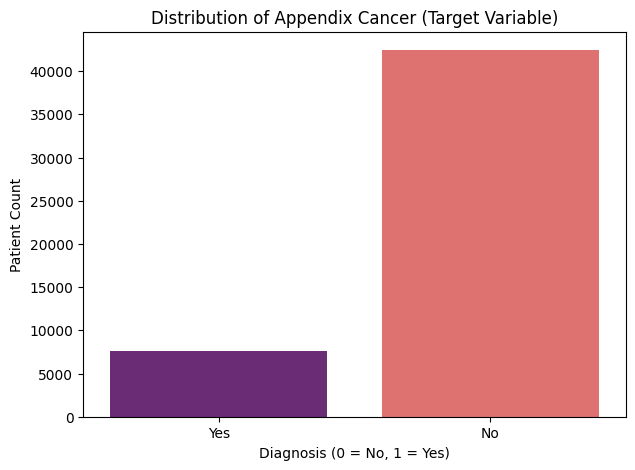

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
# Assigning x to hue and setting legend=False to satisfy the new Seaborn requirements
sns.countplot(x='Appendix_Cancer_Prediction', data=df, hue='Appendix_Cancer_Prediction', palette='magma', legend=False)
plt.title('Distribution of Appendix Cancer (Target Variable)')
plt.xlabel('Diagnosis (0 = No, 1 = Yes)')
plt.ylabel('Patient Count')
plt.show()

The countplot shows that there is a significant class imbalance in the target variable which is justifiable and typical for rare oncological conditions.While our stratified sampling preserved the initial ratio of the dataset, the "No" cases still heavily outnumber the "Yes" cases. This justifies the use of F1-Score and Recall as our primary metrics later, as Accuracy alone would be misleading in an imbalanced scenario.

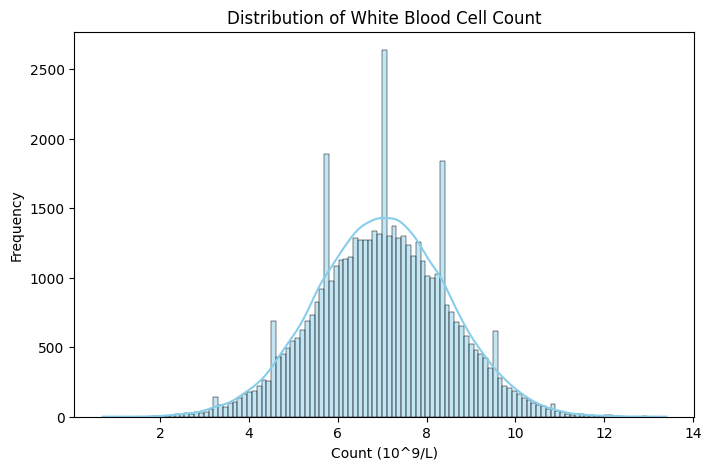

In [16]:
# Histogram for Blood Cell Counts
plt.figure(figsize=(8, 5))
sns.histplot(df['White_Blood_Cell_Count'], kde=True, color='skyblue')
plt.title('Distribution of White Blood Cell Count')
plt.xlabel('Count (10^9/L)')
plt.ylabel('Frequency')
plt.show()

From the above histogram, we can observe that most patients fall within the healthy clinical range when it comes to white blood cell count.Althought there are spikes in the middle of the mentioned range which suggests that there are more than normal counts of some specific values of white blood cell distributions.

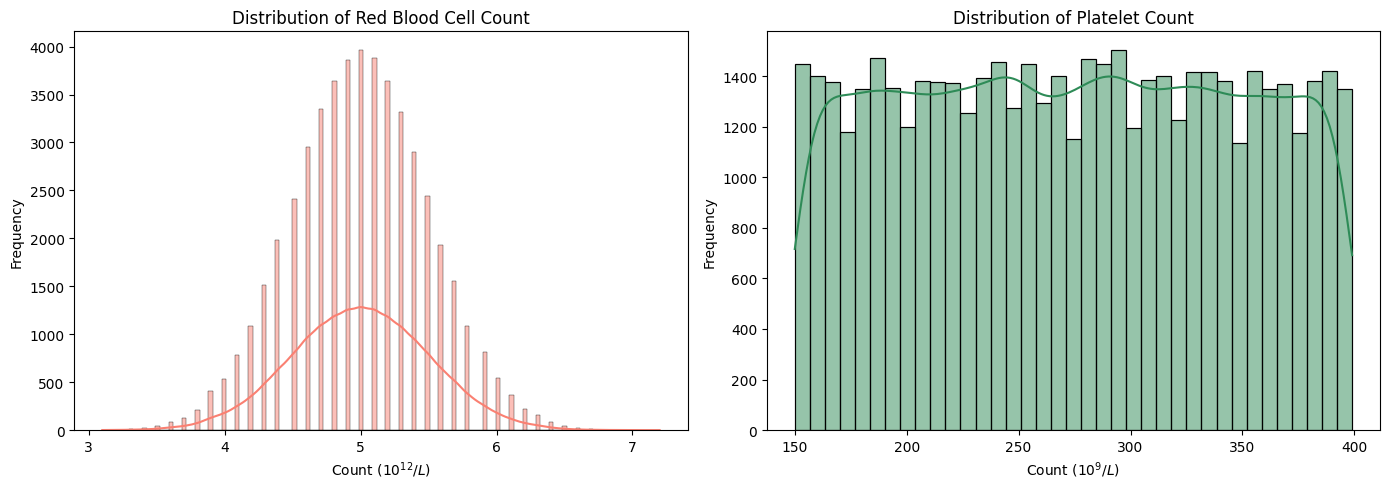

In [17]:
# Set up a figure with two subplots side-by-side
plt.figure(figsize=(14, 5))

# Subplot 1: Red Blood Cell Count
plt.subplot(1, 2, 1)
sns.histplot(df['Red_Blood_Cell_Count'], kde=True, color='salmon')
plt.title('Distribution of Red Blood Cell Count')
plt.xlabel('Count ($10^{12}/L$)')
plt.ylabel('Frequency')

# Subplot 2: Platelet Count
plt.subplot(1, 2, 2)
sns.histplot(df['Platelet_Count'], kde=True, color='seagreen')
plt.title('Distribution of Platelet Count')
plt.xlabel('Count ($10^9/L$)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

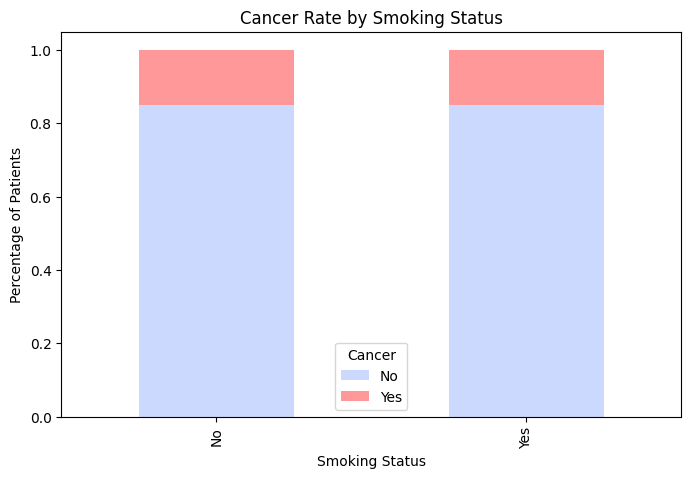

In [18]:
# Cross-tabulation of a category vs the cancer prediction
ct = pd.crosstab(df['Smoking_Status'], df['Appendix_Cancer_Prediction'], normalize='index')

ct.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#ccd9ff', '#ff9999'])
plt.title('Cancer Rate by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Percentage of Patients')
plt.legend(title='Cancer', labels=['No', 'Yes'])
plt.show()

We can observe from the above figure that in this specific dataset, Smoking Status does not appear to change your risk of Appendix Cancer. If one pink bar was much taller than the other, it would be a "strong predictor." Since they are equal, it's a "weak predictor."

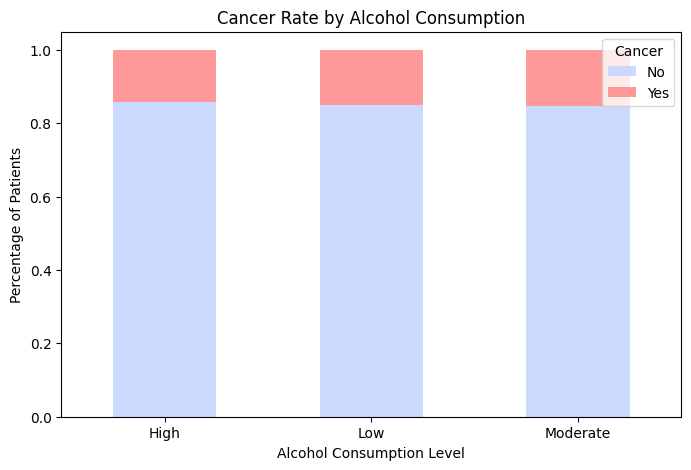

In [19]:
# Create the cross-tabulation for Alcohol Consumption
# 'normalize=index' converts the raw counts into percentages (0.0 to 1.0)
ct_alcohol = pd.crosstab(df['Alcohol_Consumption'], df['Appendix_Cancer_Prediction'], normalize='index')

# Plot the stacked bar chart
# We use the same color scheme for consistency in your report
ct_alcohol.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#ccd9ff', '#ff9999'])

# Add labels and title
plt.title('Cancer Rate by Alcohol Consumption')
plt.xlabel('Alcohol Consumption Level')
plt.ylabel('Percentage of Patients')
plt.legend(title='Cancer', labels=['No', 'Yes'], loc='upper right')
plt.xticks(rotation=0)

plt.show()

We can observe that in this dataset, the alcohol consumption behaviour also doesn't make much of a difference on cancer prediction

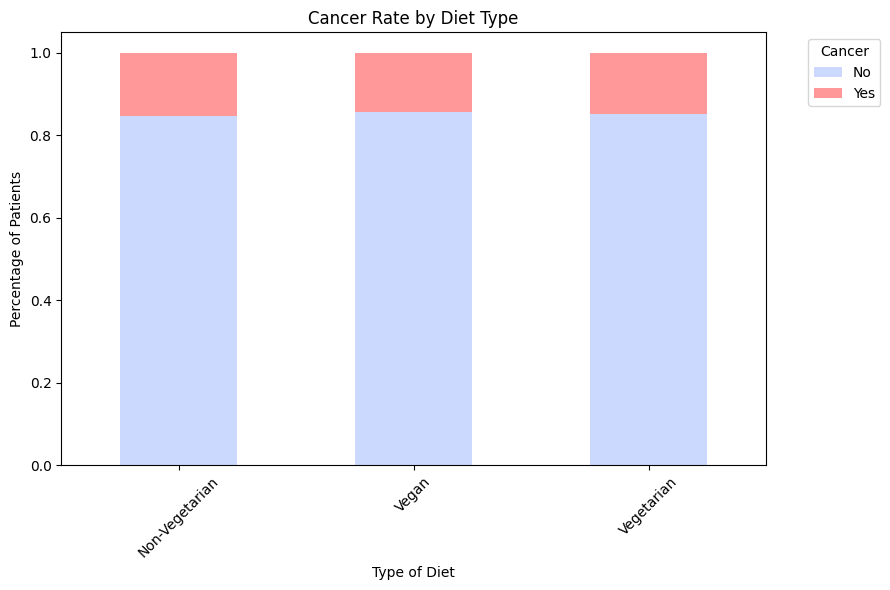

In [20]:
# Creating the cross-tabulation for Diet Type
# 'normalize=index' makes it easy to compare percentages across groups of different sizes
ct_diet = pd.crosstab(df['Diet_Type'], df['Appendix_Cancer_Prediction'], normalize='index')

# Plotting the results
ct_diet.plot(kind='bar', stacked=True, figsize=(9, 6), color=['#ccd9ff', '#ff9999'])

# Formatting for your report
plt.title('Cancer Rate by Diet Type')
plt.xlabel('Type of Diet')
plt.ylabel('Percentage of Patients')
plt.legend(title='Cancer', labels=['No', 'Yes'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45) # Tilts names like 'Vegetarian' so they don't overlap

plt.tight_layout()
plt.show()

We can observe that in this dataset, the diet type of a patient also doesn't make much of a difference on cancer prediction.

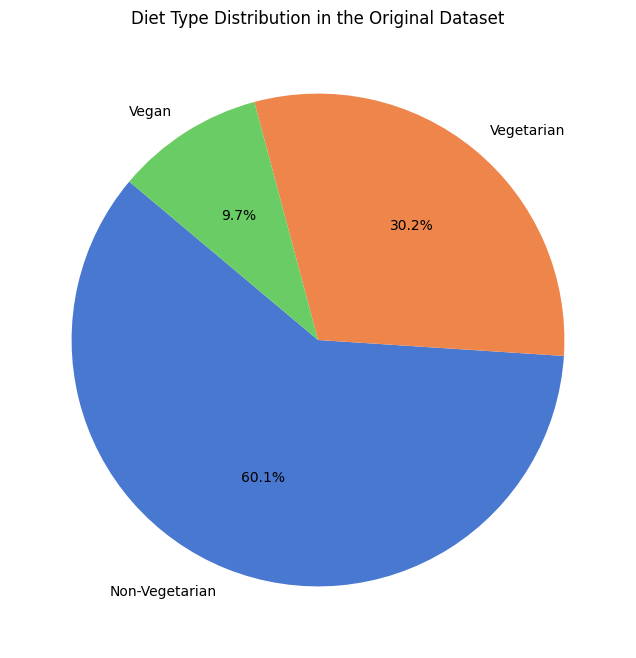

In [21]:
# Counting the occurrences of each diet type in the entire original dataset
original_diet_counts = df['Diet_Type'].value_counts()

# Creating the pie chart for the original distribution
plt.figure(figsize=(8, 8))
plt.pie(original_diet_counts,
        labels=original_diet_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('muted')) # Using a different palette to distinguish from the filtered chart

plt.title('Diet Type Distribution in the Original Dataset')
plt.show()

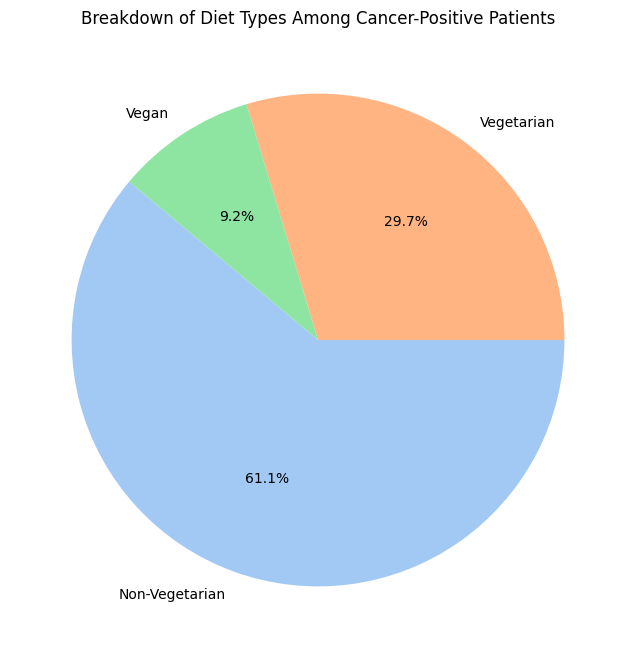

In [22]:

# Filter the data to only include those with a positive diagnosis
cancer_yes_df = df[df['Appendix_Cancer_Prediction'] == 'Yes']

# Count the occurrences of each diet type in this group
diet_counts = cancer_yes_df['Diet_Type'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(diet_counts,
        labels=diet_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))

plt.title('Breakdown of Diet Types Among Cancer-Positive Patients')
plt.show()

We can observe from the above two piecharts that the distributions of diet_type in our original dataset and cancer positive group that the distributions are almost the same.

In [23]:
import pandas as pd

# BINARY ENCODING (Yes/No, Male/Female)
# Mapping these to 0 and 1.
binary_mapping = {'Yes': 1, 'No': 0, 'Positive': 1, 'Negative': 0}

binary_cols = [
    'Smoking_Status', 'Family_History_Cancer',
    'Genetic_Mutations', 'Radiation_Exposure',
    'Previous_Cancers', 'Tumor_Markers','Appendix_Cancer_Prediction'
]

for col in binary_cols:
    df[col] = df[col].map(binary_mapping)

# ORDINAL ENCODING (Ranked Categories)
ordinal_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
severity_mapping = {'Mild': 0, 'Moderate': 1, 'Severe': 2}

df['Alcohol_Consumption'] = df['Alcohol_Consumption'].map(ordinal_mapping)
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].map(ordinal_mapping)
df['Symptom_Severity'] = df['Symptom_Severity'].map(severity_mapping)

# NOMINAL ENCODING (One-Hot Encoding)
nominal_cols = ['Country', 'Chronic_Diseases', 'Diet_Type', 'Gender']

df_final = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Encoding Complete!")
print(f"Original columns: {df.shape[1]}")
print(f"New columns after encoding: {df_final.shape[1]}")

Encoding Complete!
Original columns: 22
New columns after encoding: 48


In [24]:
df_final['Appendix_Cancer_Prediction']

,Appendix_Cancer_Prediction
0,1
1,1
2,0
3,0
4,0
...,...
49995,1
49996,0
49997,0
49998,0


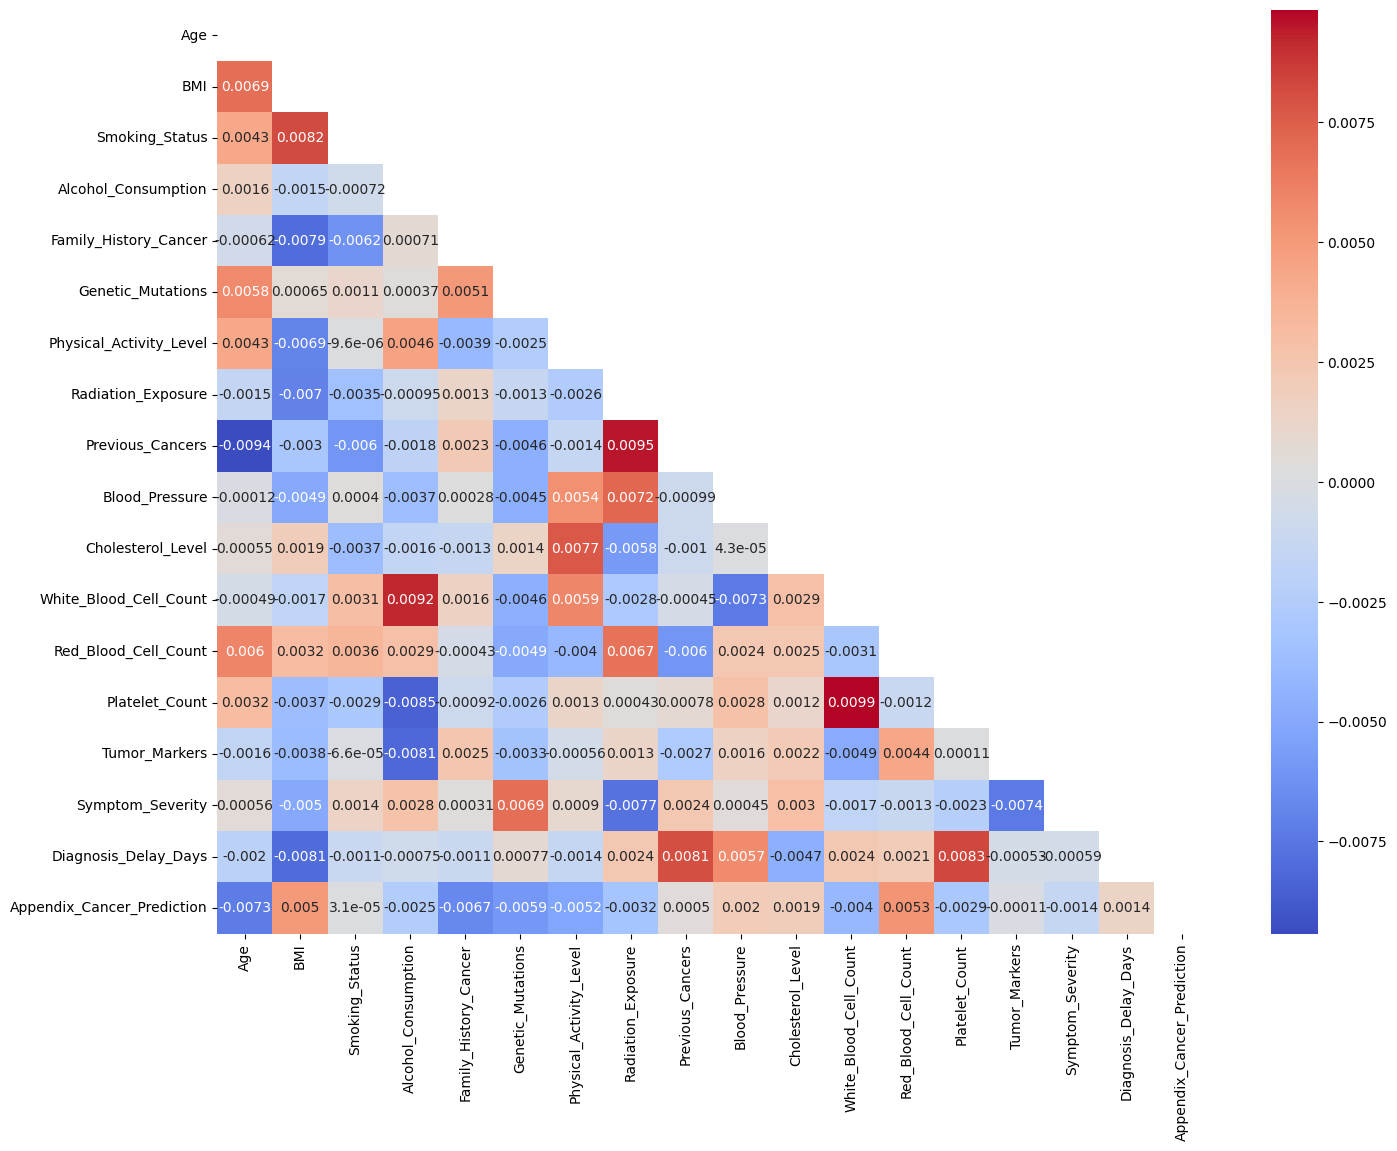

In [25]:
# Force selection of ONLY numeric columns
numeric_only_df = df_final.select_dtypes(include=['number'])

# Running the correlation on filtered data
corr_matrix = numeric_only_df.corr()

import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm')
plt.show()

From the above correlation matrix, it can be observed that almost none of the feature columns have any correlation with the target appendix cancer, with all correlations being essentially zero. This shows that the data is either randomly generated (synthetic data) or none of the features have a linear relationship with the target variable

# Building a Neural network

In [26]:
# Separating Features (X) and Target (y)
X = df_final.drop('Appendix_Cancer_Prediction', axis=1)
y = df_final['Appendix_Cancer_Prediction']

# Split the dataset
# We use 'stratify=y' to keep the 15% cancer ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
# Fitting the scaler ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Split and Scaled successfully!")
print(f"Training shapes: {X_train_scaled.shape}, Test shapes: {X_test_scaled.shape}")

Data Split and Scaled successfully!
Training shapes: (40000, 47), Test shapes: (10000, 47)


In [27]:

# Initialize the Neural Network (MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Train the model
# Using the scaled data we prepared earlier
mlp.fit(X_train_scaled, y_train)

# Evaluate on Training Set
y_train_pred = mlp.predict(X_train_scaled)
print("--- TRAINING SET PERFORMANCE ---")
print(classification_report(y_train, y_train_pred))

# Evaluate on Test Set
y_test_pred = mlp.predict(X_test_scaled)
print("\n--- TEST SET PERFORMANCE ---")
print(classification_report(y_test, y_test_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


--- TRAINING SET PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     33956
           1       0.67      0.40      0.50      6044

    accuracy                           0.88     40000
   macro avg       0.78      0.68      0.72     40000
weighted avg       0.87      0.88      0.87     40000


--- TEST SET PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      8489
           1       0.15      0.11      0.12      1511

    accuracy                           0.77     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.74      0.77      0.76     10000



# Building primary model(Two Classical ML models)

In [28]:
from sklearn.metrics import classification_report

# Initialize the Models
# We use class_weight='balanced' because of your 15% cancer imbalance
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
rand_forest = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Train Models
print("Training Logistic Regression...")
log_reg.fit(X_train_scaled, y_train)

print("Training Random Forest...")
rand_forest.fit(X_train_scaled, y_train)

# LOGISTIC REGRESSION EVALUATION ---
print("\n" + "="*50)
print("LOGISTIC REGRESSION PERFORMANCE")
print("="*50)

# Training Set Evaluation
print("\n[TRAINING SET]")
y_train_pred_log = log_reg.predict(X_train_scaled)
print(classification_report(y_train, y_train_pred_log))

# Test Set Evaluation
print("\n[TEST SET]")
y_test_pred_log = log_reg.predict(X_test_scaled)
print(classification_report(y_test, y_test_pred_log))


# RANDOM FOREST EVALUATION
print("\n" + "="*50)
print("RANDOM FOREST PERFORMANCE")
print("="*50)

# Training Set Evaluation
print("\n[TRAINING SET]")
y_train_pred_rf = rand_forest.predict(X_train_scaled)
print(classification_report(y_train, y_train_pred_rf))

# Test Set Evaluation
print("\n[TEST SET]")
y_test_pred_rf = rand_forest.predict(X_test_scaled)
print(classification_report(y_test, y_test_pred_rf))

Training Logistic Regression...
Training Random Forest...

LOGISTIC REGRESSION PERFORMANCE

[TRAINING SET]
              precision    recall  f1-score   support

           0       0.86      0.53      0.66     33956
           1       0.16      0.51      0.24      6044

    accuracy                           0.53     40000
   macro avg       0.51      0.52      0.45     40000
weighted avg       0.75      0.53      0.59     40000


[TEST SET]
              precision    recall  f1-score   support

           0       0.85      0.53      0.65      8489
           1       0.15      0.46      0.22      1511

    accuracy                           0.52     10000
   macro avg       0.50      0.49      0.44     10000
weighted avg       0.74      0.52      0.58     10000


RANDOM FOREST PERFORMANCE

[TRAINING SET]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33956
           1       1.00      1.00      1.00      6044

    accuracy        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Evaluation

While the Random Forset achieved a higher overall accuracy(85%), it failed as a classifier by predicting the majority class for all samples, resulting in a Recall of 0 for cancer cases. As we saw in the heatmap the absence of strong feature correlations led the model to minimizing it's loss by defaulting to a majority-class prediction strategy.

Conversely, Logistic Regression performed the best because it was able to identify a significant portion of cancer cases(Recall: 0.46). Even though it's precision is low(0.15) due to the lack of feature correlation, it proves to be more effective than a model that misses every positive case.

#  Hyperparameter optimization with Cross-Validation

In [29]:
from sklearn.model_selection import GridSearchCV

# Tuning Logistic Regression
print("Tuning Logistic Regression...")
log_param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear'] # Good for small/medium datasets
}

grid_log = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    log_param_grid,
    cv=3,
    scoring='f1',
    verbose=1
)
grid_log.fit(X_train_scaled, y_train)

# Tuning Random Forest
print("\nTuning Random Forest...")
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_param_grid,
    cv=3,
    scoring='f1',
    verbose=1
)
grid_rf.fit(X_train_scaled, y_train)

# Reporting the Results
print("\n" + "="*30)
print("LOGISTIC REGRESSION BEST PARAMS:")
print(grid_log.best_params_)
print(f"Best CV F1-Score: {grid_log.best_score_:.4f}")

print("\nRANDOM FOREST BEST PARAMS:")
print(grid_rf.best_params_)
print(f"Best CV F1-Score: {grid_rf.best_score_:.4f}")
print("="*30)

Tuning Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Tuning Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

LOGISTIC REGRESSION BEST PARAMS:
{'C': 0.1, 'solver': 'liblinear'}
Best CV F1-Score: 0.2310

RANDOM FOREST BEST PARAMS:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1-Score: 0.1615


# Feature Selection

## Feature Selection For Logistic Regression and Random Forest

In [30]:
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFE

# Initialize RFE
# We tell it to select the 10 most important features
rfe_selector = RFE(estimator=log_reg, n_features_to_select=10, step=1)

# Fit RFE
rfe_selector.fit(X_train_scaled, y_train)

# Get the names of the selected columns
selected_features_log = X.columns[rfe_selector.support_].tolist()


# Random Forest Feature Selection
# We use the optimized model from Task 4
selector_rf = SelectFromModel(rand_forest, prefit=True)
# Get the names of the features that passed the importance threshold
selected_features_rf = X.columns[selector_rf.get_support()].tolist()

# Print the Results
print(f"Task 5 Complete!")
print("-" * 30)
print(f"Logistic Regression: {len(selected_features_log)} features selected.")
print("Selected Features:", selected_features_log)

print("-" * 30)
print(f"Random Forest: {len(selected_features_rf)} features selected.")
print("Selected Features:", selected_features_rf)

Task 5 Complete!
------------------------------
Logistic Regression: 10 features selected.
Selected Features: ['Genetic_Mutations', 'Blood_Pressure', 'Country_Australia', 'Country_China', 'Country_Egypt', 'Country_Turkey', 'Chronic_Diseases_Hypertension', 'Chronic_Diseases_None', 'Diet_Type_Vegan', 'Diet_Type_Vegetarian']
------------------------------
Random Forest: 11 features selected.
Selected Features: ['Age', 'BMI', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Blood_Pressure', 'Cholesterol_Level', 'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Platelet_Count', 'Symptom_Severity', 'Diagnosis_Delay_Days']


 # Final Models and Comparative Analysis

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#Filter the datasets using the selected features from Task 5
X_train_log_final = X_train_scaled[:, rfe_selector.support_]
X_test_log_final = X_test_scaled[:, rfe_selector.support_]

# selector_rf matches your Task 5 code
X_train_rf_final = X_train_scaled[:, selector_rf.get_support()]
X_test_rf_final = X_test_scaled[:, selector_rf.get_support()]

#Rebuild both models using optimal hyperparameters from Task 4
final_log_model = LogisticRegression(C=0.1, solver='liblinear', class_weight='balanced', random_state=42)
final_rf_model = RandomForestClassifier(max_depth=10, min_samples_split=2, n_estimators=50, class_weight='balanced', random_state=42)

#Train the final models
final_log_model.fit(X_train_log_final, y_train)
final_rf_model.fit(X_train_rf_final, y_train)

#Generate Predictions
y_pred_log = final_log_model.predict(X_test_log_final)
y_pred_rf = final_rf_model.predict(X_test_rf_final)

#Create Table 4
table_4_data = [
    {
        "Model": "Logistic Regression",
        "Features": f"Selected ({len(selected_features_log)})",
        "CV Score": round(grid_log.best_score_, 2),
        "Accuracy": round(accuracy_score(y_test, y_pred_log), 2),
        "Precision": round(precision_score(y_test, y_pred_log), 2),
        "Recall": round(recall_score(y_test, y_pred_log), 2),
        "F1-Score": round(f1_score(y_test, y_pred_log), 2)
    },
    {
        "Model": "Random Forest",
        "Features": f"Selected ({len(selected_features_rf)})",
        "CV Score": round(grid_rf.best_score_, 2),
        "Accuracy": round(accuracy_score(y_test, y_pred_rf), 2),
        "Precision": round(precision_score(y_test, y_pred_rf), 2),
        "Recall": round(recall_score(y_test, y_pred_rf), 2),
        "F1-Score": round(f1_score(y_test, y_pred_rf), 2)
    }
]

table_4 = pd.DataFrame(table_4_data)

print("Table 4: Comparison of Final Classification Models")
print("-" * 85)
print(table_4.to_string(index=False))
print("-" * 85)

Table 4: Comparison of Final Classification Models
-------------------------------------------------------------------------------------
              Model      Features  CV Score  Accuracy  Precision  Recall  F1-Score
Logistic Regression Selected (10)      0.23      0.47       0.15    0.55      0.24
      Random Forest Selected (11)      0.16      0.68       0.15    0.23      0.18
-------------------------------------------------------------------------------------


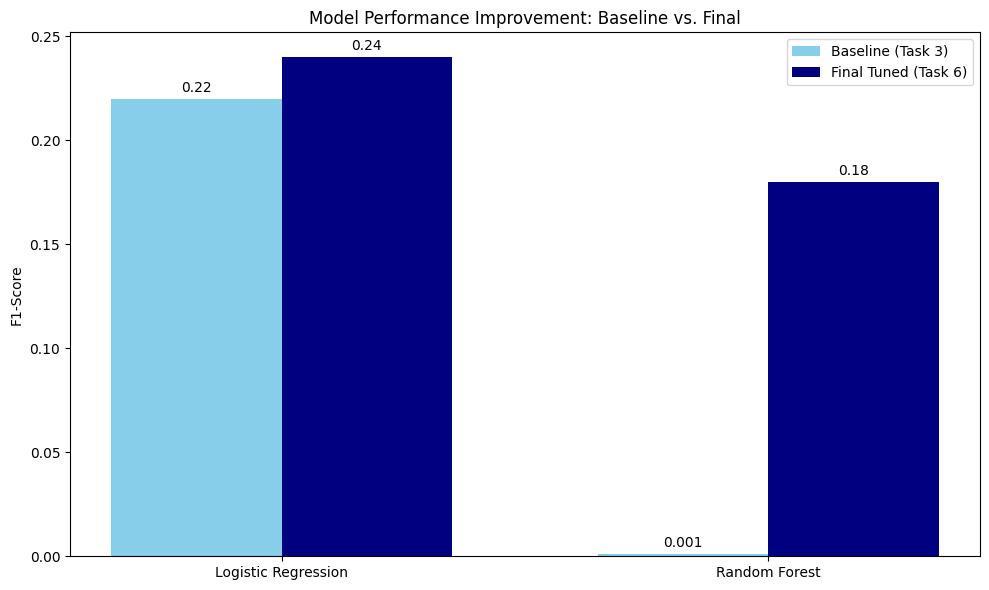

In [32]:
import matplotlib.pyplot as plt
import numpy as np


baseline_f1 = [0.22, 0.001]  # [LogReg, Random Forest (we include 0.001 instead of plain 0)]
final_f1 = [0.24, 0.18]     # From Table 4 results

labels = ['Logistic Regression', 'Random Forest']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, baseline_f1, width, label='Baseline (Task 3)', color='skyblue')
rects2 = ax.bar(x + width/2, final_f1, width, label='Final Tuned (Task 6)', color='navy')

ax.set_ylabel('F1-Score')
ax.set_title('Model Performance Improvement: Baseline vs. Final')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add value labels on top of bars
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.tight_layout()
plt.savefig('baseline_vs_final.png')

# Confusion matrix

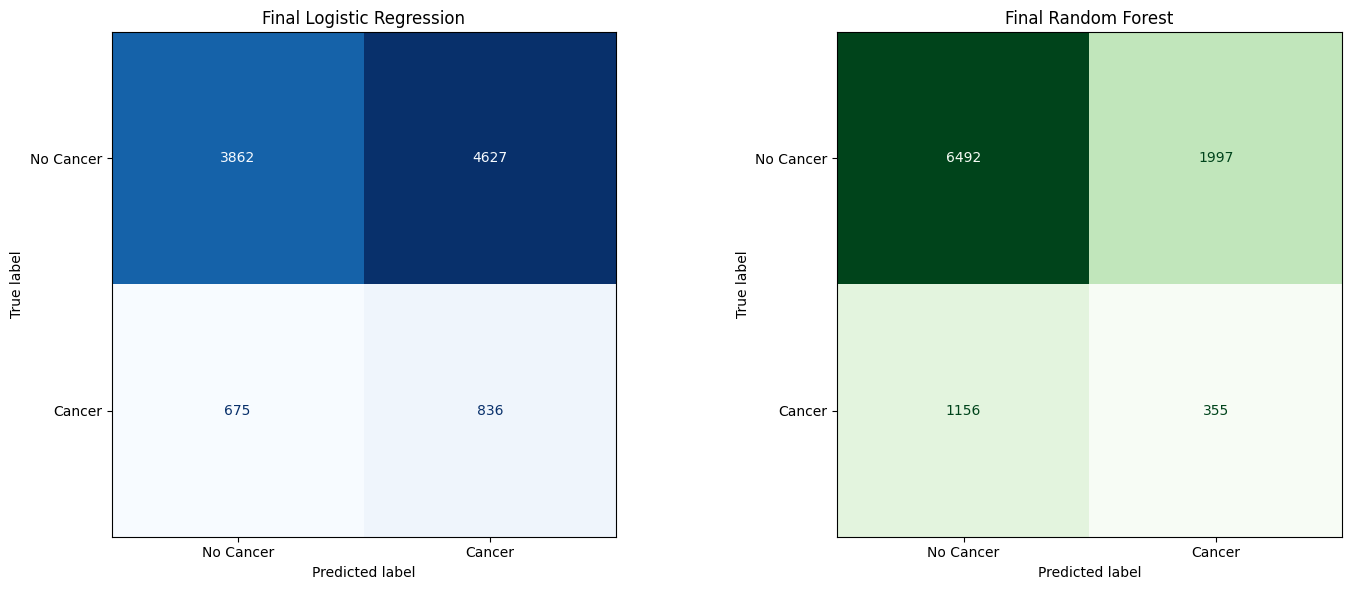

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['No Cancer', 'Cancer'])
disp_log.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Final Logistic Regression")

# Plot Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Cancer', 'Cancer'])
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title("Final Random Forest")

plt.tight_layout()
plt.savefig('confusion_matrices.png')

We can observe from the confuction matrix that the Logistic Regression model has more True positive cases for cancer, although it might be because it predicted a lot of positive values, which resulted in 4627 false positives as well.

Whereas the Random Forest model  predicted no cancer for most values and got a higher accuracy but a low value of reacall and has high value of false negatives (1156) which can be deemed dangerous in real life situations

# AUC-ROC Curve

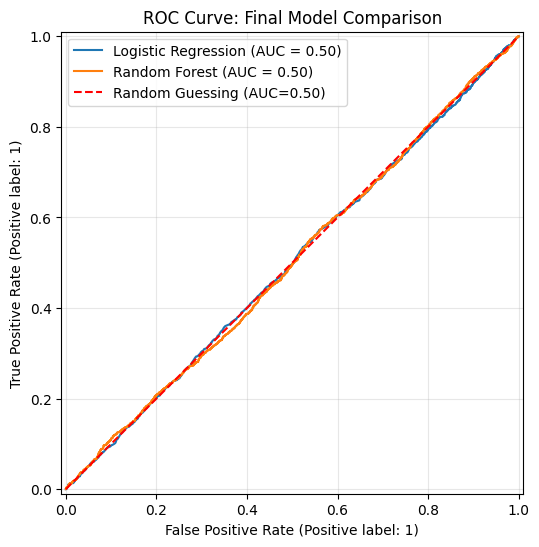

In [34]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

# Plotting ROC for Logistic Regression
RocCurveDisplay.from_estimator(final_log_model, X_test_log_final, y_test, ax=ax, name='Logistic Regression')

# Plotting ROC for Random Forest
RocCurveDisplay.from_estimator(final_rf_model, X_test_rf_final, y_test, ax=ax, name='Random Forest')

# Adding the 'Random Guess' baseline diagonal
ax.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guessing (AUC=0.50)')
ax.set_title('ROC Curve: Final Model Comparison')
ax.legend()

plt.grid(alpha=0.3)
plt.savefig('roc_auc_curve.png')

The AUC-ROC curve shows that none of the models are able to effectively distinguish between positive and negative classes and their predictive performance is no greater than chance.

This suggests issues such as weak predictive features and no sufficient signal in data.